In [4]:
import os 
import numpy as np
import pandas as pd
import scipy
import sklearn.metrics as skmetrics

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import lightning as L

import torchmetrics
from torchmetrics.regression import PearsonCorrCoef

In [5]:
aa_alphabet = 'ACDEFGHIKLMNPQRSTVWY' # amino acid alphabet
aa_to_int = {aa: i for i, aa in enumerate(aa_alphabet)} # mapping from amino acid to number

# function to one hot encode sequence
def one_hot_encode(sequence):
    # initialize a zero matrix of shape (len(sequence), len(amino_acids))
    one_hot = torch.zeros(len(sequence), len(aa_alphabet))
    for i, aa in enumerate(sequence):
        # set the column corresponding to the amino acid to 1
        one_hot[i].scatter_(0, torch.tensor([aa_to_int[aa]]), 1)
    return one_hot


# sequence data, comes already batched, so treat accordingly in dataloader (batch_size=1)
class SequenceData(Dataset):
    def __init__(self, csv_file, label_col="ddG_ML"):
        """
        Initializes the dataset. 
        input:
            csv_file: path to the relevant data file, eg. "/home/data/mega_train.csv"
        """
        self.df = pd.read_csv(csv_file, sep=",")
        self.label_col = label_col
        # only have mutation rows
        self.df = self.df[self.df.mut_type!="wt"]
        # process the mutation row
        self.df["mutation_pos"] = self.df["mut_type"].apply(lambda x: int(x[1:-1])-1) # make position start at zero
        self.df["mutation_to"] = self.df["mut_type"].apply(lambda x: aa_to_int[x[-1]]) # give numerical label to mutation

        # group by wild type
        self.df = self.df.groupby("WT_name").agg(list)
        # get wild type names
        self.wt_names = self.df.index.values
        # precompute one-hot encoding for faster training
        self.encoded_seqs = {}
        for wt_name in self.wt_names:
            # get the correct row
            mut_row = self.df.loc[wt_name]
            seq = mut_row["wt_seq"][0]
            self.encoded_seqs[wt_name] = one_hot_encode(seq)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get the wild type name
        wt_name = self.wt_names[idx]
        # get the correct row
        mut_row = self.df.loc[wt_name]
        # get the wt sequence in one hot encoding
        sequence_encoding = self.encoded_seqs[wt_name]

        # create mask and target tensors
        mask = torch.zeros((1, len(sequence_encoding),20)) # will be 1 where we have a measurement
        target = torch.zeros((1, len(sequence_encoding),20)) # ddg values
        # all mutations from df
        positions = torch.tensor(mut_row["mutation_pos"])
        amino_acids = torch.tensor(mut_row["mutation_to"])
        # get the labels
        labels = torch.tensor(mut_row[self.label_col])

        for i in range(len(sequence_encoding)):
            mask[0,i,amino_acids[positions==i]] = 1 # one where we have data
            target[0,i,amino_acids[positions==i]] = labels[positions==i] # fill with ddG values
        
        # returns encoded sequence, mask and target sequence 
        return {"sequence": sequence_encoding[None,:,:].float(), "mask": mask, "labels": target}

In [6]:
# usage
dataset_train = SequenceData('/home/course/Desktop/project_tn_data/mega_train.csv')
dataset_val= SequenceData('/home/course/Desktop/project_tn_data/mega_val.csv')
# dataset_test = SequenceData('project_data/mega_test.csv') # only once available

# use batch_size=1 bc we treat each sequence as one batch
dataloader_val = DataLoader(dataset_val, batch_size=1, shuffle=False)
dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
# dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

In [7]:
df_train = pd.read_csv("/home/course/Desktop/project_tn_data/mega_train.csv")
print(df_train.head())

   Unnamed: 0                        name    ddG_ML mut_type  \
0           0      r10_437_TrROS_Hall.pdb  0.016723       wt   
1           1  r10_437_TrROS_Hall.pdb_wty  0.090124       wt   
2           2  r10_437_TrROS_Hall.pdb_wte  0.000000       wt   
3           3  r10_437_TrROS_Hall.pdb_wtm -0.005570       wt   
4           4  r10_437_TrROS_Hall.pdb_wth -0.046900       wt   

                  WT_name                                           aa_seq  \
0  r10_437_TrROS_Hall.pdb  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP   
1  r10_437_TrROS_Hall.pdb  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP   
2  r10_437_TrROS_Hall.pdb  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP   
3  r10_437_TrROS_Hall.pdb  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP   
4  r10_437_TrROS_Hall.pdb  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP   

                                            wt_seq  
0  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP  
1  EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDI

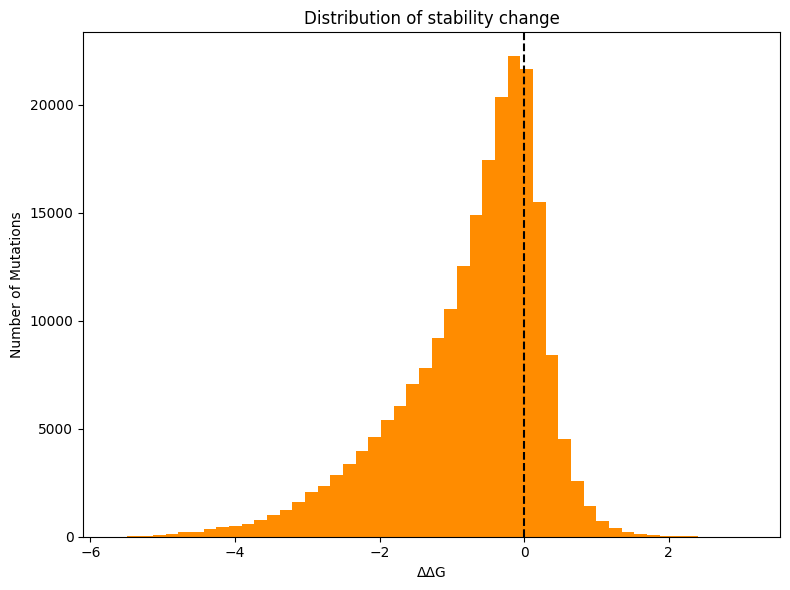

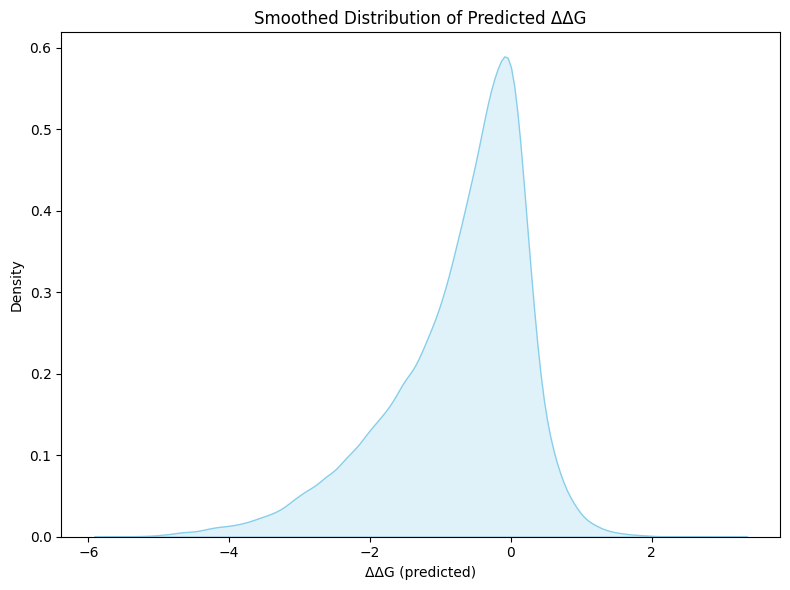

'\n# Optional: Violin plot by WT_name (if you want to see variation per wild type)\nplt.figure(figsize=(12,6))\nsns.violinplot(data=df_train[df_train[\'mut_type\'] != \'wt\'], x=\'WT_name\', y=\'ddG_ML\')\nplt.xticks(rotation=90)\nplt.ylabel("ΔΔG")\nplt.xlabel("Wild Type")\nplt.title("ΔΔG Distribution per Wild Type")\nplt.tight_layout()\nplt.show()'

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract all ΔΔG values for mutations (exclude wild type)
ddg_values = df_train[df_train['mut_type'] != 'wt']['ddG_ML']

# Histogram
plt.figure(figsize=(8,6))
plt.hist(ddg_values, bins=50, color='darkorange')
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("ΔΔG")
plt.ylabel("Number of Mutations")
plt.title("Distribution of stability change")
plt.tight_layout()
plt.show()

# Seaborn density plot (smoothed distribution)
plt.figure(figsize=(8,6))
sns.kdeplot(ddg_values, fill=True, color='skyblue')
plt.xlabel("ΔΔG (predicted)")
plt.ylabel("Density")
plt.title("Smoothed Distribution of Predicted ΔΔG")
plt.tight_layout()
plt.show()
'''
# Optional: Violin plot by WT_name (if you want to see variation per wild type)
plt.figure(figsize=(12,6))
sns.violinplot(data=df_train[df_train['mut_type'] != 'wt'], x='WT_name', y='ddG_ML')
plt.xticks(rotation=90)
plt.ylabel("ΔΔG")
plt.xlabel("Wild Type")
plt.title("ΔΔG Distribution per Wild Type")
plt.tight_layout()
plt.show()'''

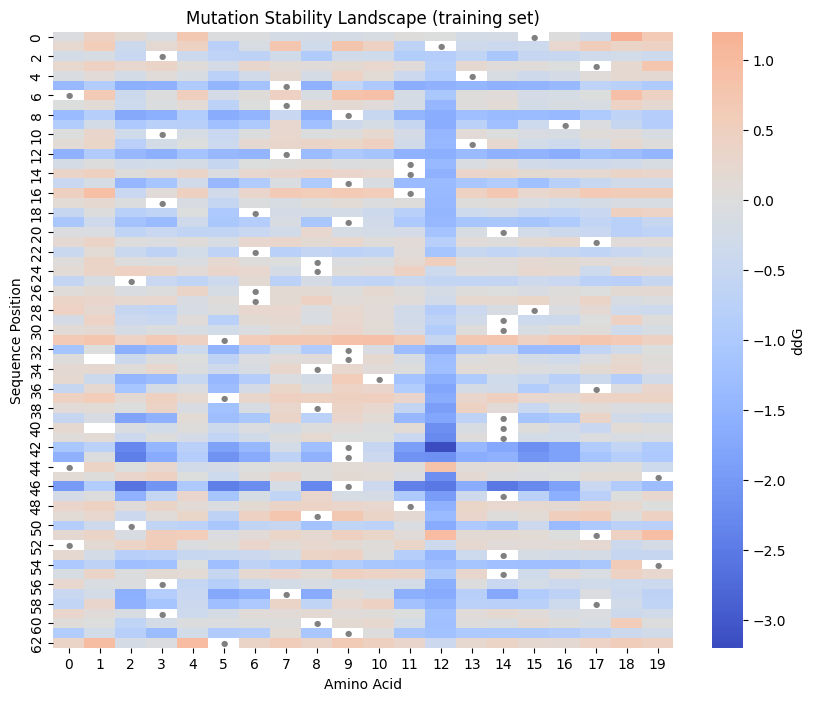

In [10]:

# get one sample
sample = dataset_train[0]

# remove batch dimension
labels = sample["labels"][0]      # shape (L, 20)
mask = sample["mask"][0]          # shape (L, 20)

# mask out missing mutations
ddg_matrix = labels.clone()
ddg_matrix[mask == 0] = float("nan")

plt.figure(figsize=(10, 8))
sns.heatmap(ddg_matrix.numpy(), 
            cmap="coolwarm", 
            center=0,
            cbar_kws={"label": "ddG"})
wt_encoding = sample["sequence"][0]   # (L, 20)
wt_indices = wt_encoding.argmax(dim=1)

for pos, aa_idx in enumerate(wt_indices):
    plt.text(aa_idx + 0.5, pos + 0.5, "●",
             ha='center', va='center', color='grey', fontsize=6)

plt.xlabel("Amino Acid")
plt.ylabel("Sequence Position")
plt.title("Mutation Stability Landscape (training set)")
plt.show()

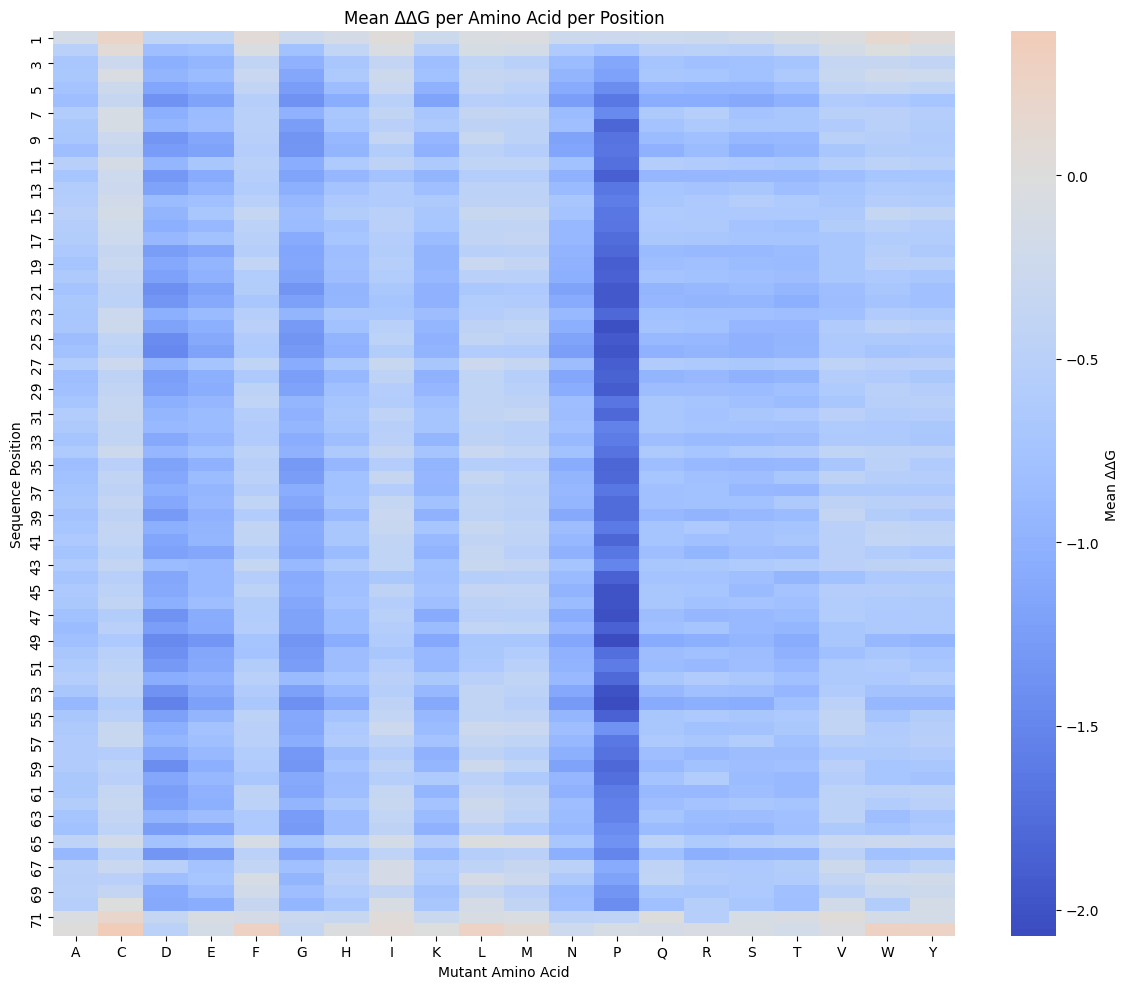

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_mut = df_train[df_train["mut_type"] != "wt"].copy()

def get_mutation(row):
    wt = row["wt_seq"]
    mut = row["aa_seq"]

    for i, (w, m) in enumerate(zip(wt, mut)):
        if w != m:
            return pd.Series([w, m, i+1])  # position is 1-based
    
    return pd.Series([np.nan, np.nan, np.nan])

df_mut[["wt_aa", "mut_aa", "position"]] = df_mut.apply(get_mutation, axis=1)

heatmap_df = (
    df_mut
    .groupby(["position", "mut_aa"])["ddG_ML"]
    .mean()
    .reset_index()
)

heatmap_matrix = heatmap_df.pivot(
    index="position",
    columns="mut_aa",
    values="ddG_ML"
)

aa_order = list("ACDEFGHIKLMNPQRSTVWY")

heatmap_matrix = heatmap_matrix.reindex(columns=aa_order)
heatmap_matrix = heatmap_matrix.sort_index()

plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_matrix,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Mean ΔΔG"}
)

plt.xlabel("Mutant Amino Acid")
plt.ylabel("Sequence Position")
plt.title("Mean ΔΔG per Amino Acid per Position")

plt.tight_layout()
plt.show()

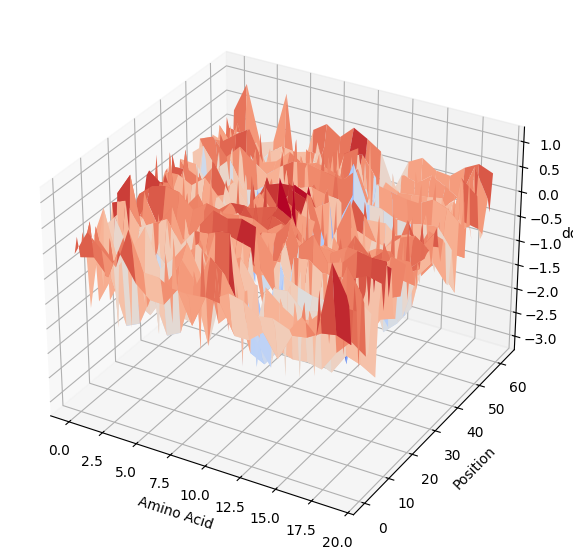

In [6]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_surface(dataset, idx=0):
    sample = dataset[idx]
    labels = sample["labels"][0]
    mask = sample["mask"][0]

    labels = labels.clone()
    labels[mask == 0] = float("nan")

    Z = labels.numpy()
    X, Y = np.meshgrid(range(20), range(Z.shape[0]))

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap="coolwarm")

    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Position")
    ax.set_zlabel("ddG")
    plt.show()

plot_3d_surface(dataset_train, idx=0)

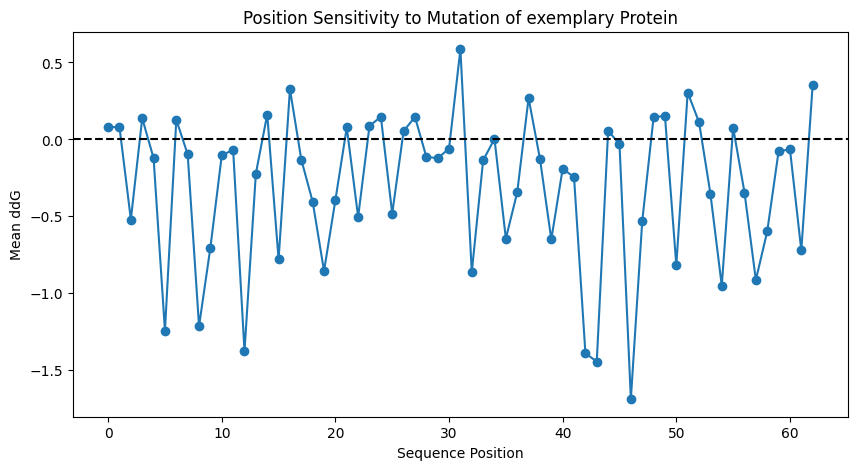

In [17]:
def plot_position_sensitivity(dataset, idx=0):
    sample = dataset[idx]
    labels = sample["labels"][0]
    mask = sample["mask"][0]

    labels = labels.clone()
    labels[mask == 0] = float("nan")

    position_mean = torch.nanmean(labels, dim=1)

    plt.figure(figsize=(10,5))
    plt.plot(position_mean.numpy(), marker="o")
    plt.xlabel("Sequence Position")
    plt.ylabel("Mean ddG")
    plt.title("Position Sensitivity to Mutation of exemplary Protein")
    plt.axhline(0, color="black", linestyle="--")
    plt.show()

plot_position_sensitivity(dataset_train, idx=0)

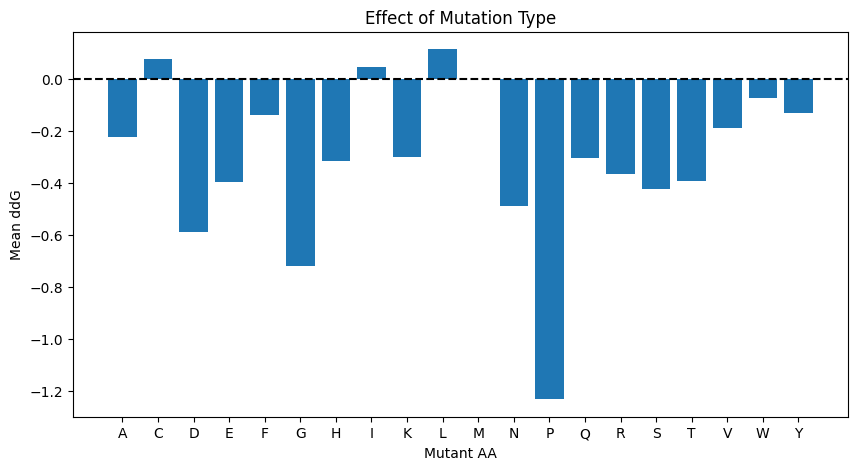

In [22]:
def plot_amino_acid_effect(dataset, idx=0):
    sample = dataset[idx]
    labels = sample["labels"][0]
    mask = sample["mask"][0]

    labels = labels.clone()
    labels[mask == 0] = float("nan")

    aa_mean = torch.nanmean(labels, dim=0)

    plt.figure(figsize=(10,5))
    plt.bar(list(aa_alphabet), aa_mean.numpy())
    plt.ylabel("Mean ddG")
    plt.xlabel("Mutant AA")
    plt.title("Effect of Mutation Type")
    plt.axhline(0, color="black", linestyle="--")
    plt.show()

plot_amino_acid_effect(dataset_train, 0)
#to or form proline


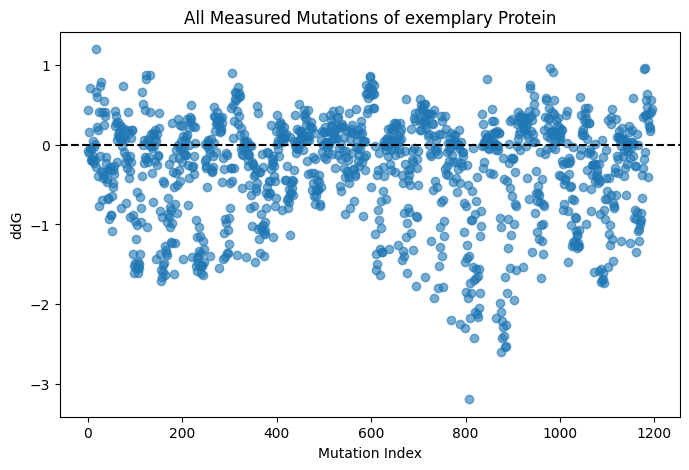

In [18]:
def plot_scatter_mutations(dataset, idx=0):
    sample = dataset[idx]
    labels = sample["labels"][0]
    mask = sample["mask"][0]

    ddg_values = labels[mask == 1]

    plt.figure(figsize=(8,5))
    plt.scatter(range(len(ddg_values)), ddg_values.numpy(), alpha=0.6)
    plt.axhline(0, color="black", linestyle="--")

    plt.xlabel("Mutation Index")   # <-- added
    plt.ylabel("ddG")
    plt.title("All Measured Mutations of exemplary Protein")

    plt.show()

plot_scatter_mutations(dataset_train, 0)

In [10]:
'''
def plot_scatter_mutations_with_avg(dataset, idx=0):
    sample = dataset[idx]
    labels = sample["labels"][0]  # (L, 20)
    mask = sample["mask"][0]      # (L, 20)

    # Flatten measured mutations
    ddg_values = labels[mask == 1]
    
    # Get sequence positions for each measured mutation
    positions = torch.nonzero(mask).numpy()  # shape: (num_mutations, 2)
    seq_positions = positions[:, 0]
    aa_indices = positions[:, 1]

    plt.figure(figsize=(10,5))

    # Scatter plot: x=sequence position, y=ddG, color=mutated amino acid
    scatter = plt.scatter(
        seq_positions,
        ddg_values.numpy(),
        c=aa_indices,
        cmap="tab20",
        alpha=0.7
    )

    # Average line across positions
    # Compute mean ddG per position
    L = labels.shape[0]
    avg_ddg = np.full(L, np.nan)
    for i in range(L):
        ddg_at_pos = ddg_values[seq_positions == i]
        if len(ddg_at_pos) > 0:
            avg_ddg[i] = ddg_at_pos.mean().item()
    plt.plot(range(L), avg_ddg, color="black", linestyle="--", linewidth=2, label="Average ΔΔG per position")

    plt.axhline(0, color="gray", linestyle=":", linewidth=1)
    plt.xlabel("Sequence Position")
    plt.ylabel("ΔΔG")
    plt.title(f"Measured Mutations for {dataset.wt_names[idx]}")
    plt.colorbar(scatter, label="Mutated Amino Acid Index")
    plt.legend()
    plt.show()

plot_scatter_mutations_with_avg(dataset_train,0)
'''

'\ndef plot_scatter_mutations_with_avg(dataset, idx=0):\n    sample = dataset[idx]\n    labels = sample["labels"][0]  # (L, 20)\n    mask = sample["mask"][0]      # (L, 20)\n\n    # Flatten measured mutations\n    ddg_values = labels[mask == 1]\n\n    # Get sequence positions for each measured mutation\n    positions = torch.nonzero(mask).numpy()  # shape: (num_mutations, 2)\n    seq_positions = positions[:, 0]\n    aa_indices = positions[:, 1]\n\n    plt.figure(figsize=(10,5))\n\n    # Scatter plot: x=sequence position, y=ddG, color=mutated amino acid\n    scatter = plt.scatter(\n        seq_positions,\n        ddg_values.numpy(),\n        c=aa_indices,\n        cmap="tab20",\n        alpha=0.7\n    )\n\n    # Average line across positions\n    # Compute mean ddG per position\n    L = labels.shape[0]\n    avg_ddg = np.full(L, np.nan)\n    for i in range(L):\n        ddg_at_pos = ddg_values[seq_positions == i]\n        if len(ddg_at_pos) > 0:\n            avg_ddg[i] = ddg_at_pos.mean()

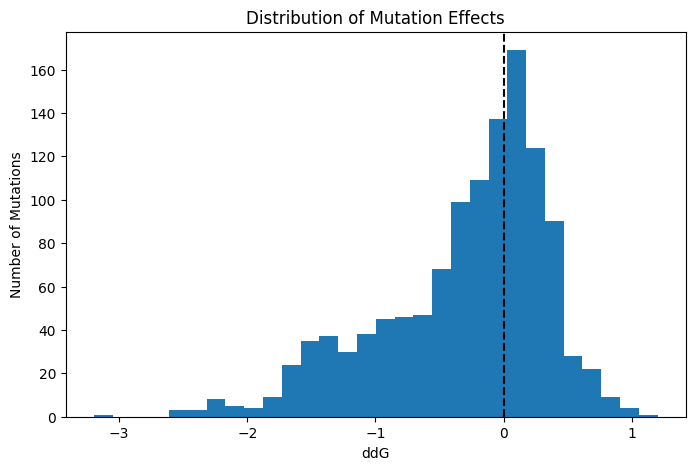

In [11]:
def plot_ddg_distribution(dataset, idx=0):
    sample = dataset[idx]
    labels = sample["labels"][0]
    mask = sample["mask"][0]

    ddg_values = labels[mask == 1]

    plt.figure(figsize=(8,5))
    plt.hist(ddg_values.numpy(), bins=30)
    plt.axvline(0, color="black", linestyle="--")
    plt.xlabel("ddG")
    plt.ylabel("Number of Mutations")  # <-- added
    plt.title("Overview on stability change")
    plt.show()

plot_ddg_distribution(dataset_train, 0)
#number of mutations that fall into this bar

In [21]:

# remove WT rows if needed
df_train_nowt = df_train[df_train.mut_type != "wt"]

# get wild-type sequences only (unique proteins)
wt_sequences = df_train_nowt.groupby("WT_name")["wt_seq"].first()

# compute lengths
seq_lengths = wt_sequences.apply(len)

print(seq_lengths)
max(seq_lengths)
min(seq_lengths)



WT_name
1A32.pdb       63
1AOY.pdb       69
1E0L.pdb       37
1E6H.pdb       61
1ENH.pdb       48
               ..
v2_2HDZ.pdb    50
v2_2LXE.pdb    53
v2_2M5A.pdb    56
v2_4UZX.pdb    58
v2_6IVS.pdb    48
Name: wt_seq, Length: 239, dtype: int64


35

In [22]:

max(seq_lengths)

72

In [14]:
x=counter(df_train["wt_seq"]==df_train["aa_seq"])
print(x)
'''
num_unique_proteins = train_seq["WT_name"].nunique()
print(num_unique_proteins)
'''

NameError: name 'counter' is not defined

In [15]:
print("Min length:", seq_lengths.min())
print("Max length:", seq_lengths.max())
print("Mean length:", seq_lengths.mean())
print("Median length:", seq_lengths.median())

Min length: 35
Max length: 72
Mean length: 50.71129707112971
Median length: 48.0


In [16]:
print(seq_lengths.value_counts().head())

wt_seq
43    55
40    31
56    12
63     9
55     9
Name: count, dtype: int64


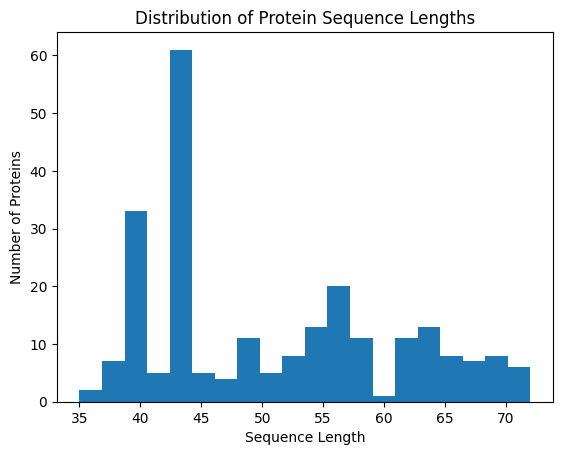

In [17]:

plt.hist(seq_lengths, bins=20)
plt.xlabel("Sequence Length")
plt.ylabel("Number of Proteins")
plt.title("Distribution of Protein Sequence Lengths")
plt.show()

In [18]:
mut_counts = df_train.groupby("wt_seq").size()
print(mut_counts.describe())

count     239.000000
mean      907.610879
std       194.931800
min       559.000000
25%       758.000000
50%       870.000000
75%      1053.500000
max      1361.000000
dtype: float64


In [19]:
from collections import Counter
wt_seq = "".join(df_train["wt_seq"].unique())
aa_counts = Counter(wt_seq)
print(aa_counts)

Counter({'E': 1341, 'K': 1266, 'L': 1035, 'A': 924, 'V': 832, 'T': 729, 'R': 688, 'D': 687, 'G': 642, 'I': 635, 'N': 558, 'Q': 507, 'S': 485, 'Y': 415, 'F': 395, 'P': 352, 'H': 221, 'W': 204, 'M': 203, 'C': 1})


In [ ]:
#also look at validation
#validation and training have distinct proteins counting the unique sequences